<a href="https://colab.research.google.com/github/shreya-parchure/SLP-vs-LLM-Aphasia/blob/main/Guide_Using_Whisper_LLM_to_Transcribe_Speech_in_Aphasia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Important Note about Protected Health Information (PHI):

**This tutorial is meant for illustrative purposes only. When using actual patient data, please be mindful to:**

- Use the local version of Whisper by download from Git (that does not connect to the internet, so that no recordings will be processed on OpenAI servers).
- Upload audio files to temporary runtime storage if trying this tutorial (rather than saving on Google Drive).
- Use anonymized, deidentified versions of the recordings so that there is no PHI.

# Whisper for ASR in Aphasia: A Low-Code Tutorial

Whisper is an automated speech recognition (ASR) model developed by OpenAI, trained on a large dataset of diverse audio. Use of this large language model (LLM) AI technology is rapidly growing in language research to transcribe human speech audio recordings. One such use might be automated transcription of clinical language testing used to assess abilities and deficits in people with aphasia, or acquired language impairment.

**Despite its growing popularity these LLM ASR tools have not been extensively tested for transcription in aphasia.** While this tutorial contains a guide for how to use Whisper, we urge caution and appropriate use based on understanding of its capabilities and limitations, as described in our paper. We note that due to the inherent architecture, it is going to lexicalize phonological errors.

Phoneme-Based ASR: A suite of models finetuned to recognise the smallest unit of speech distinguishing one word from another, e.g. the element p in "tap". Whisper also uses Forced Alignment - the process by which orthographic transcriptions are aligned to audio recordings to automatically generate phone level segmentation.

Access Github for more information [here](https://github.com/m-bain/whisperX?tab=readme-ov-file).


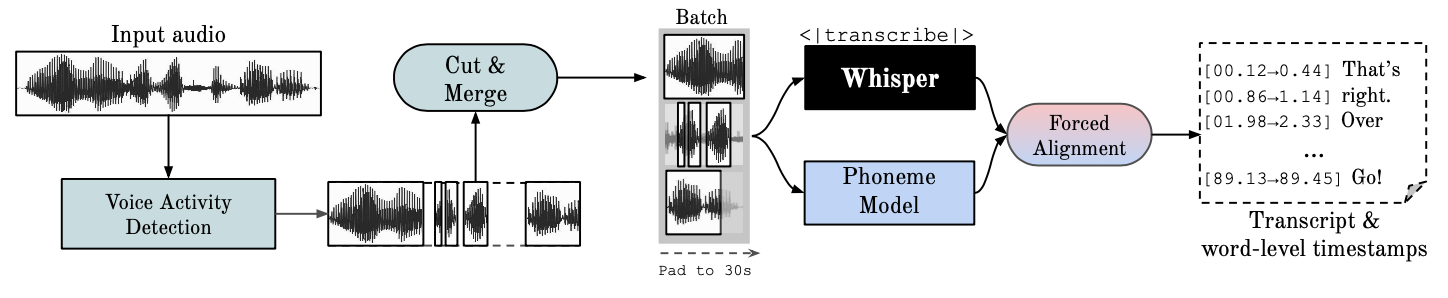

# Step One: Install Whisper & Dependencies

Run each block of code by clicking on the play button, to install the latest commit from the Whisper repository on Github.



In [ ]:
# this code imports the key libraries
!pip install -U openai-whisper
!sudo apt update && sudo apt install ffmpeg

import whisper
import numpy as np
import os
import pandas as pd
import io
from google.colab import drive
from google.colab import files

If Whisper does not get installed from above then use the below line of code:

`!pip install git+https://github.com/openai/whisper.git`

**Install ffmpeg**

You need to install [ffmpeg](https://ffmpeg.org), a cross-platform solution to record, convert and stream audio and video. Just run the cell to install.

In [ ]:
!sudo apt update && sudo apt install ffmpeg

# Step Two: Upload Your File

**IMPORTANT: PLEASE BE CAREFUL OF PHI AS PER NOTE AT THE START**

Open the file folder on the left-hand corner of your Colab notebook. Drag the .mp3 you would like to transcribe into the "Files" section.

This will upload the audio to your session storage which is temporary runtime (not permanently saved on Google Drive). Here's what it looks like once you've uploaded a file:

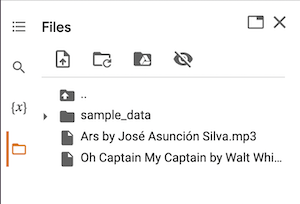




# Step Three: Transcribe

To transcribe, simply copy and paste the title of your audio file including the extension (.mp3, .wav, etc.) into the line below and run the cell.

Don't forget the quotation marks!



In [ ]:
!whisper "/content/audio_filename.wav" --model turbo

# Step 4: Save and download the transcript file

Download from session storage with the code below.


NOTE: Transcripts are saved in the session storage as a variety of formats (.tsv, .csv, etc.)

Give them a few minutes to load. Remember to download from there!

In [ ]:
files.download("transcript_filename.txt")# change the filename to match what appears in the session storage

# Step 5 (Optional): Advanced and Troubleshooting Issues

## Common issues and solutions:

Choose a different model type based on [this link](https://github.com/openai/whisper?tab=readme-ov-file#available-models-and-languages)

Default model for a balance between fast runtime and less lexicalization of errors is `medium.en` but another one that works well is `base.en`

For issues with the same line of transcript repeating, try solutions [here](https://github.com/openai/whisper/discussions/192)

This often occurs due to intermixed silences, so try to splice out any silences in the audio file.

##To transcribe multiple files:

In [ ]:
filenames = ["_____","______","______"] # fill in the file names with extension inside quotes

In [ ]:
model = whisper.load_model("medium.en") # change the model type if needed

In [ ]:
transcripts = [] # this is a blank array which will contain all outputs
for f in filenames:
  print(f) # the file name being run is printed in output below
  result = model.transcribe(f)
  print(result["text"]) # followed by its transcript printed in the ouput below
  transcripts.append(result["text"])

In [ ]:
df = pd.DataFrame(transcripts)
df.to_csv("all_transcripts", index=False)